In [1]:
!pip install fsspec s3fs

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 200 kB 17.1 MB/s            
     |████████████████████████████████| 87 kB 12.2 MB/s            
     |████████████████████████████████| 1.7 MB 92.2 MB/s            
     |████████████████████████████████| 240 kB 67.3 MB/s            
     |████████████████████████████████| 14.3 MB 101.9 MB/s            
     |████████████████████████████████| 81 kB 17.9 MB/s            
     |████████████████████████████████| 219 kB 83.6 MB/s            
     |████████████████████████████████| 197 kB 92.5 MB/s            
     |████████████████████████████████| 346 kB 89.3 MB/s            
     |████████████████████████████████| 44 kB 5.2 MB/s             
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
boto3 1.42.86 requires botocore<1.43.0,>=1.42.86, but you 

In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 109.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 64.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 99.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 112.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 37.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
import json
import os
import boto3
import time

headers = {
    "Authorization": "Bearer STUDENT_TOKEN_2026"
}

#url_latest = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/latest?station_id=GDN_01"
url_batch = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/batch?station_id=GDN_01&limit=100"
#url_stations = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/stations"
stations = ["GDN_01","GDN_02","GDY_01","SOP_01"]

all_data = []
for stacja in stations:
    url_batch = f"https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/batch?station_id={stacja}&limit=100"
    response = requests.get(url_batch, headers=headers)
    
    if response.status_code == 200:
        data = response.json()
        print("Udało się pobrać dane")
        all_data.extend(data["records"])
        
    time.sleep(0.5)
        
s3 = boto3.client('s3')

BUCKET_NAME = 'aws-logs-003693136002-us-east-1' 

FILE_OUT = 'raw_data.json'
json_data_string = json.dumps(all_data, indent=4)

try:
    s3.put_object(
        Bucket=BUCKET_NAME,
        Key=FILE_OUT,
        Body=json_data_string,
        ContentType='application/json'
    )
    print(f"Plik został zapisany pod adresem: s3://{BUCKET_NAME}/{FILE_OUT}")
except Exception as e:
    print(e)
        

Udało się pobrać dane
Udało się pobrać dane
Udało się pobrać dane
Udało się pobrać dane
Plik został zapisany pod adresem: s3://aws-logs-003693136002-us-east-1/raw_data.json


In [2]:
import boto3
import pandas as pd
import json

BUCKET_NAME = 'aws-logs-003693136002-us-east-1'
FILE_IN = 'raw_data.json'
FILE_OUT = f's3://{BUCKET_NAME}/validated_data.csv'

s3 = boto3.client('s3')
response = s3.get_object(Bucket=BUCKET_NAME, Key=FILE_IN)    
file_content = response['Body'].read().decode('utf-8')
raw_data = json.loads(file_content)
    
df = pd.DataFrame(raw_data)
    
    
df['timestamp'] = pd.to_datetime(df['timestamp'])
    
print(df.isnull().sum())
df = df.dropna()
    
df_clean = df[
        (df['wind_speed'] >= 0) & 
        (df['humidity'] >= 0) & 
        (df['humidity'] <= 100)
]
try:
    df_clean.to_csv(FILE_OUT, index=False)
    print(f"Oczyszczone dane po walidacji zostały zapisane w S3: {FILE_OUT}")
except Exception as e:
    print(e)


timestamp         0
station_id        0
temperature       0
humidity          0
pressure          0
wind_speed        0
wind_direction    0
rain_mm           0
cloud_cover       0
dtype: int64
Oczyszczone dane po walidacji zostały zapisane w S3: s3://aws-logs-003693136002-us-east-1/validated_data.csv


,station_id,timestamp,wind_speed_mean,wind-risk_score,cycling_risk,running_risk,field_work_risk
0,GDN_01,2026-06-27 04:00:00+00:00,6.460000,6.14,7.95,6.46,4.03
1,GDN_01,2026-06-27 05:00:00+00:00,8.736667,8.44,10.00,8.74,6.59
2,GDN_01,2026-06-27 06:00:00+00:00,8.965000,8.58,10.00,8.96,6.77
3,GDN_01,2026-06-27 07:00:00+00:00,7.135000,6.89,8.85,7.14,4.70
4,GDN_01,2026-06-27 08:00:00+00:00,8.226667,8.14,10.00,8.23,6.18


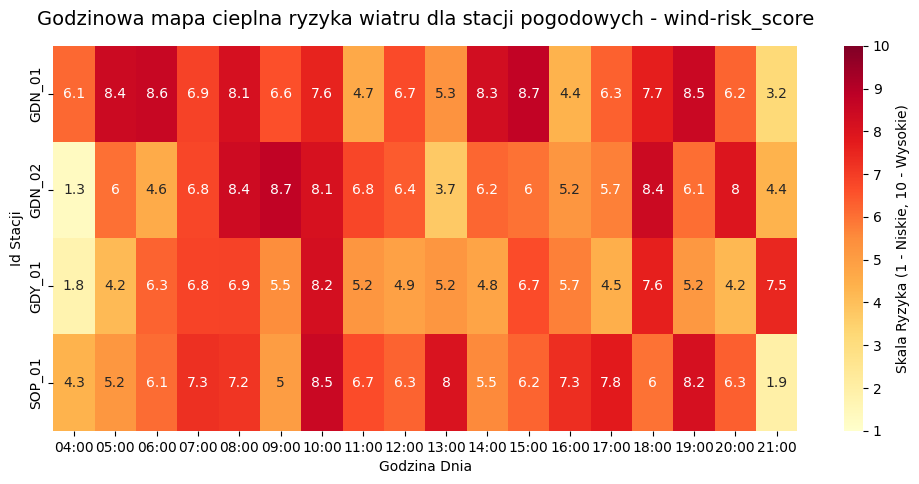

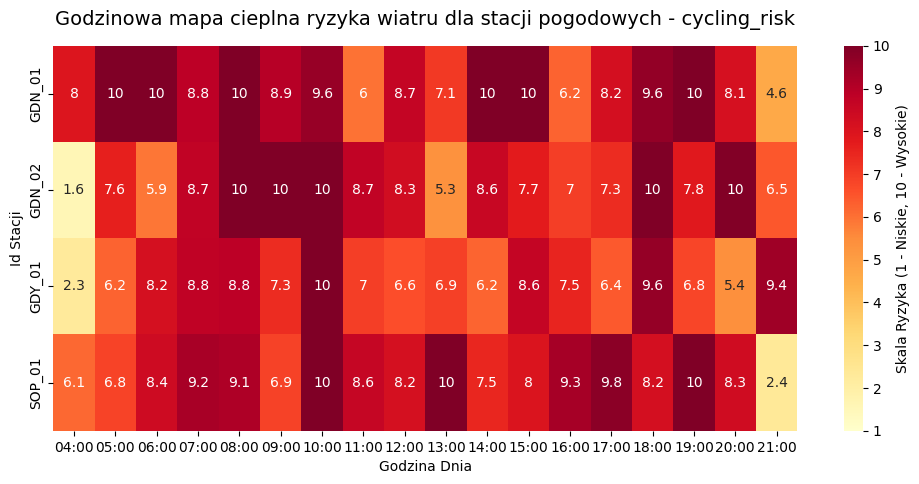

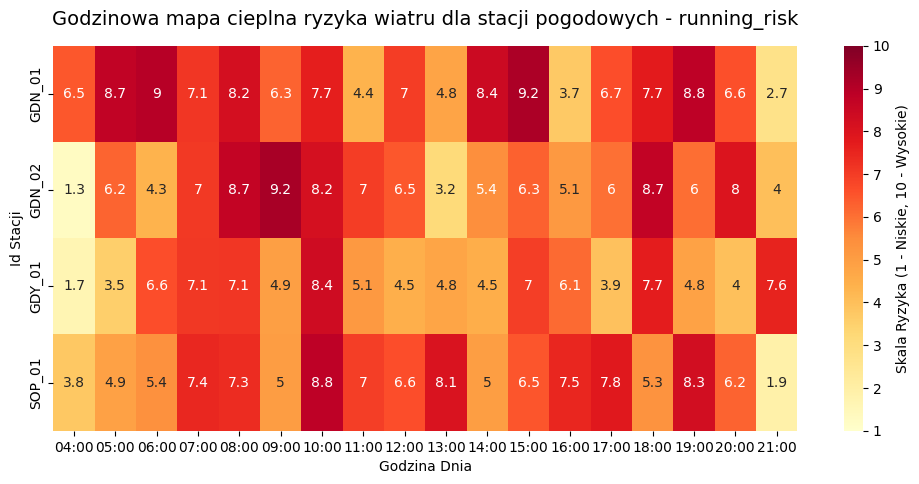

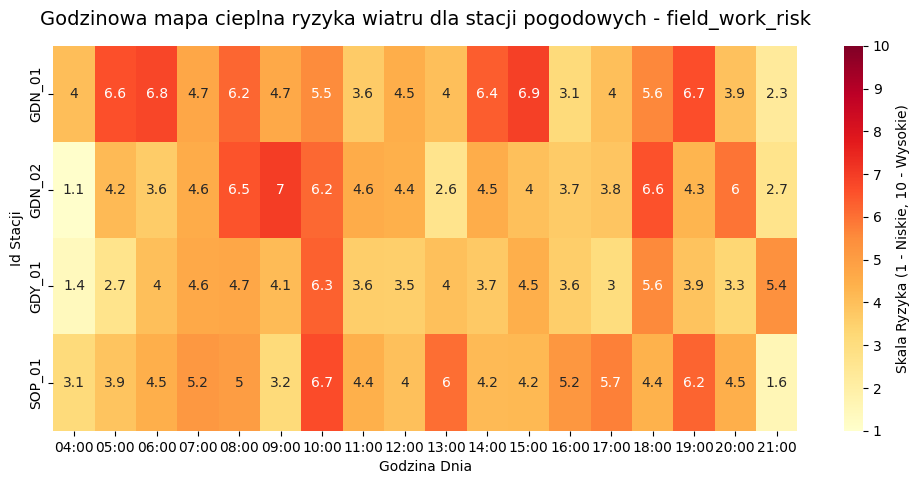

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BUCKET_NAME = 'aws-logs-003693136002-us-east-1'
FILE_IN = f's3://{BUCKET_NAME}/validated_data.csv'

df_clean = pd.read_csv(FILE_IN)
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

df_resampled = df_clean.set_index('timestamp')

df_hourly = df_resampled.groupby('station_id').resample('H').agg({
    'wind_speed': ['mean', 'max'],
    'temperature': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'rain_mm': 'sum',      
    'cloud_cover': 'mean'
})

df_hourly.columns = ['_'.join(col).strip() for col in df_hourly.columns.values]
df_hourly = df_hourly.reset_index()


def ocen_ryzyko(row):
    sredni_wiatr = row['wind_speed_mean']
    maks_wiatr = row['wind_speed_max']
    
    
    cyc_mean = np.interp(sredni_wiatr, [0, 3, 5, 8], [0.0, 3.0, 6.0, 10.0])
    cyc_max = np.interp(maks_wiatr, [0, 11, 15], [0.0, 6.0, 10.0])
    cycling_risk = max(cyc_mean, cyc_max)
    
    run_mean = np.interp(sredni_wiatr, [0, 4, 6, 10], [0.0, 3.0, 6.0, 10.0])
    run_max = np.interp(maks_wiatr, [0, 15, 20], [0.0, 6.0, 10.0])
    running_risk = max(run_mean, run_max)
    
    field_mean = np.interp(sredni_wiatr, [0, 5, 8, 13], [0.0, 3.0, 6.0, 10.0])
    field_max = np.interp(maks_wiatr, [0, 18, 24], [0.0, 6.0, 10.0])
    field_risk = max(field_mean, field_max)
        
    risk_score = (cycling_risk + running_risk + field_risk) / 3
        
    return pd.Series([risk_score, cycling_risk, running_risk, field_risk], 
                     index=['wind-risk_score', 'cycling_risk', 'running_risk', 'field_work_risk'])

df_analiza = df_hourly.apply(ocen_ryzyko, axis=1)
df_final = pd.concat([df_hourly, df_analiza], axis=1)
risk_col = ['wind-risk_score', 'cycling_risk', 'running_risk', 'field_work_risk']
df_final[risk_col] = df_final[risk_col].round(2)

display(df_final[['station_id', 'timestamp', 'wind_speed_mean', 'wind-risk_score', 'cycling_risk', 'running_risk','field_work_risk']].head())


df_final['godzina'] = df_final['timestamp'].dt.strftime('%H:%M')
risk_scores = ['wind-risk_score', 'cycling_risk', 'running_risk', 'field_work_risk']

for i in risk_scores:
    macierz_ryzyka = df_final.pivot(index='station_id', columns='godzina', values=f'{i}')

    plt.figure(figsize=(12, 5))
    sns.heatmap(macierz_ryzyka, annot=True, cmap='YlOrRd', vmin=1, vmax=10, 
            cbar_kws={'label': 'Skala Ryzyka (1 - Niskie, 10 - Wysokie)'})
    plt.title(f'Godzinowa mapa cieplna ryzyka wiatru dla stacji pogodowych - {i}', fontsize=14, pad=15)
    plt.ylabel('Id Stacji')
    plt.xlabel('Godzina Dnia')
    plt.show()